In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# load the data
df = pd.read_csv('IMDB Dataset.csv')
print(df.shape)
df.head()

(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
# Check the basics 
#Positiv vs negative review
print(df['sentiment'].value_counts())

#missing values
print(df.isnull().sum())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64
review       0
sentiment    0
dtype: int64


In [4]:
# print one positive and negative review

pos_review = df[df['sentiment'] == 'positive']['review'].iloc[0]
neg_review = df[df['sentiment'] == 'negative']['review'].iloc[0]

print("Positive Review: ")
print(pos_review)

print("====================")

print("\nNegative Review: ")
print(neg_review)
      

Positive Review: 
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show

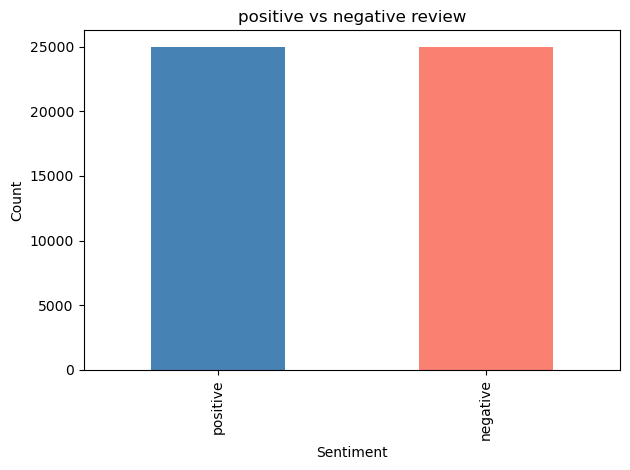

In [5]:
# Plot Distribution
df['sentiment'].value_counts().plot(kind ='bar', color = ['steelblue', 'salmon'])
plt.title('positive vs negative review')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Data cleaning and processing

In [6]:
# Install NLTK
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /Users/ymans/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/ymans/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [7]:
# Import nltk
import re
from nltk.corpus import stopwords

In [8]:
# Text cleaning function
def clean_text(text):
    #remove html tags
    text = re.sub(r'<.*?>', '', text)
    
    #remove URLs
    text = re.sub(r'http\S+|www\s+', '', text)
    
    #remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # convert to lowercase
    text = text.lower()
    
    # remove stopwords
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    #Join words back in sentences
    text = ' '.join(words)
    
    return text

In [9]:
# Test in one review
sample = df['review'].iloc[0]
print("Before cleaning: \n")
print(sample)
print("\n After cleaning: ")
print(clean_text(sample))

Before cleaning: 

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the sho

In [10]:
# Apply cleaning to all data
df['cleaned_review'] = df['review'].apply(clean_text)

In [11]:
#compare original vs cleaned side by side
print("Original: ")
print(df['review'].iloc[0])
print("\nCleaned: ")
print(df['cleaned_review'].iloc[0])

Original: 
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due

In [12]:
# Check the dataframe
df.head()

,review,sentiment,cleaned_review
0,One of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


In [13]:
# Save the cleaned data
df.to_csv('IMDB_cleaned.csv', index = False)
print("Saved!")

Saved!


In [14]:
# verify it works
df_check = pd.read_csv('IMDB_cleaned.csv')
print(df_check.shape)
df_check.head()

(50000, 3)


,review,sentiment,cleaned_review
0,One of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


## Train the model

In [15]:
# import the cleaned csv
df = pd.read_csv('IMDB_cleaned.csv')
print(df.shape)
df.head()

(50000, 3)


,review,sentiment,cleaned_review
0,One of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


In [16]:
# import libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [17]:
# split data into train and test
x = df['cleaned_review']
y = df['sentiment']


In [18]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state = 42
)

print("Training size: ", len(x_train))
print("Testing size: ", len(x_test))

Training size:  40000
Testing size:  10000


In [19]:
# convert Text to Numbers using TF-IDF

# create the vectorizer
tfidf = TfidfVectorizer(max_features = 5000)

# Learn vocabulary from training data and transform it
x_train_tfidf = tfidf.fit_transform(x_train)

# transform test data using same vocabulary
x_test_tfidf = tfidf.transform(x_test)

print("Training matrix shape: ",x_train_tfidf.shape)
print("Testing matrix shape: ",x_test_tfidf.shape)

Training matrix shape:  (40000, 5000)
Testing matrix shape:  (10000, 5000)


In [20]:
# Train the model
model = LogisticRegression(max_iter=1000)

# train
model.fit(x_train_tfidf, y_train)

print("Model trained successfully ")

Model trained successfully 


In [21]:
# Test the model
y_pred = model.predict(x_test_tfidf)

# check accuracy
print("Accuracy: ",accuracy_score(y_test, y_pred))

# Detailed report
print(classification_report(y_test, y_pred))

Accuracy:  0.8868
              precision    recall  f1-score   support

    negative       0.90      0.87      0.88      4961
    positive       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



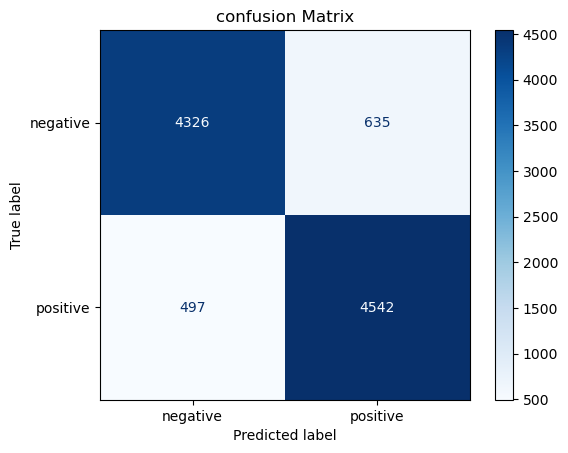

In [22]:
## confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# create confusion matrix
cm = confusion_matrix(y_test, y_pred)


#plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['negative','positive'])
disp.plot(cmap='Blues')
plt.title('confusion Matrix')
plt.show()

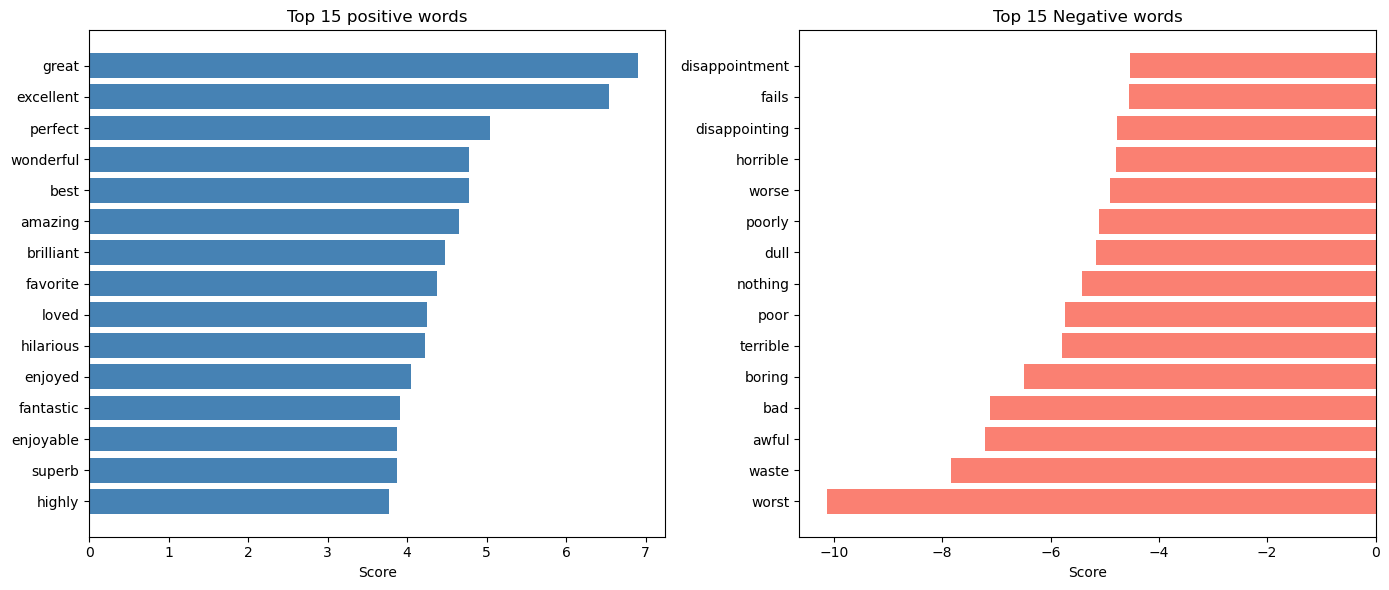

In [23]:
# Visualiza the most important words

# get features names (all 5000 words)
feature_names = np.array(tfidf.get_feature_names_out())

#get model coefficients
coefficients = model.coef_[0]

# get top 15 positive and negative words
top_positive_idx = coefficients.argsort()[-15:]
top_negative_idx = coefficients.argsort()[:15]

top_positive_words = feature_names[top_positive_idx]
top_negative_words = feature_names[top_negative_idx]

top_positive_scores = coefficients[top_positive_idx]
top_negative_scores = coefficients[top_negative_idx]

#plot
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,6))

#positive words
ax1.barh(top_positive_words, top_positive_scores, color = 'steelblue')
ax1.set_title('Top 15 positive words')
ax1.set_xlabel('Score')

# Negative score
ax2.barh(top_negative_words, top_negative_scores, color='salmon')
ax2.set_title('Top 15 Negative words')
ax2.set_xlabel('Score')

plt.tight_layout()
plt.show()

In [24]:
# Test our own review

def predict_sentiment(review):
    
    #clean review
    cleaned = clean_text(review)
    
    #convert to numbers
    vectorized = tfidf.transform([cleaned])
    
    #predict
    prediction = model.predict(vectorized)[0]
    confidence = model.predict_proba(vectorized)[0]
    
    print(f"Review: {review}")
    print(f"Sentiment: {prediction.upper()}")
    print(f"Confidence: {round(max(confidence)*100, 2)}%")

In [25]:
# Test 1 - positive
predict_sentiment("This movie was absolutely amazing, I loved every minute of it!")

# Test 2 - negative
predict_sentiment("Terrible movei, complete waste of time, worst film I have ever seen")

# Test 3 - tricky one
predict_sentiment("The movie started slow but ended beautifully")


Review: This movie was absolutely amazing, I loved every minute of it!
Sentiment: POSITIVE
Confidence: 95.19%
Review: Terrible movei, complete waste of time, worst film I have ever seen
Sentiment: NEGATIVE
Confidence: 99.99%
Review: The movie started slow but ended beautifully
Sentiment: POSITIVE
Confidence: 65.55%


## Save the Model

In [26]:
import pickle

#save the model
with open('model.pkl', 'wb') as f:
    pickle.dump(model,f)
    
#save TF-IDF vectorizer
with open('tfidf.pkl','wb') as f:
    pickle.dump(tfidf, f)
    
print("Model and vectorizer saved successfully")

Model and vectorizer saved successfully


## Install Streamlit

In [27]:
pip install streamlit

  Obtaining dependency information for streamlit from https://files.pythonhosted.org/packages/dc/e6/412c1e1f200ca8c32ecf10201839183e261ad61ced3ede34a66f6d4be3cf/streamlit-1.55.0-py3-none-any.whl.metadata
  Obtaining dependency information for altair!=5.4.0,!=5.4.1,<7,>=4.0 from https://files.pythonhosted.org/packages/db/33/ef2f2409450ef6daa61459d5de5c08128e7d3edb773fefd0a324d1310238/altair-6.0.0-py3-none-any.whl.metadata
  Obtaining dependency information for cachetools<8,>=5.5 from https://files.pythonhosted.org/packages/06/f3/39cf3367b8107baa44f861dc802cbf16263c945b62d8265d36034fc07bea/cachetools-7.0.5-py3-none-any.whl.metadata
  Obtaining dependency information for gitpython!=3.1.19,<4,>=3.0.7 from https://files.pythonhosted.org/packages/6a/09/e21df6aef1e1ffc0c816f0522ddc3f6dcded766c3261813131c78a704470/gitpython-3.1.46-py3-none-any.whl.metadata
  Obtaining dependency information for pydeck<1,>=0.8.0b4 from https://files.pythonhosted.org/packages/ab/4c/b888e6cf58bd9db9c93f40d1c6be82